In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from src.data_process import UpdateCsv

/opt/miniconda3/envs/bm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
data_file = "/Users/vuongdai/Desktop/backup_canari/DATA_HQ_TDSB/GRAF-CASC/DAT/LTU/LTUBAR/EXT/LTU002ESAPRG920.DAT"
df_raw = pd.read_csv(data_file,
                     sep=";",  # Semicolon as delimiter
                     quotechar='"',
                     engine="python",
                     na_values=[""],  # Treat empty strings as NaN
                     skipinitialspace=True,
                     encoding="ISO-8859-1",
                     )

In [3]:
df_raw.head()

,No extensometre,Amenagement,Ouvrage,Unnamed: 3,Date,Nombre Date,Ext/Contraction (mm),Remarque,Niveau reservoir (m),Memo,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,LTU002ESAPRG920,LTU,LTUBAR,NaN,1998-01-29 10:00,35824.42,0.05,NaN,151.48,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LTU002ESAPRG920,LTU,LTUBAR,NaN,1998-01-30 00:00,35825.00,0.01,NaN,151.67,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LTU002ESAPRG920,LTU,LTUBAR,NaN,1998-01-31 00:00,35826.00,-0.03,NaN,151.78,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LTU002ESAPRG920,LTU,LTUBAR,NaN,1998-02-01 00:00,35827.00,-0.07,NaN,151.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LTU002ESAPRG920,LTU,LTUBAR,NaN,1998-02-02 00:00,35828.00,-0.10,NaN,151.73,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
sensor_name = "LTU001EFAPRG900"
df = df_raw[["Ext/Contraction (mm)"]]
df.columns = ["y"]
df.index = pd.to_datetime(df_raw["Date"])
# Resampling to weekly
df = df.resample("W").last()

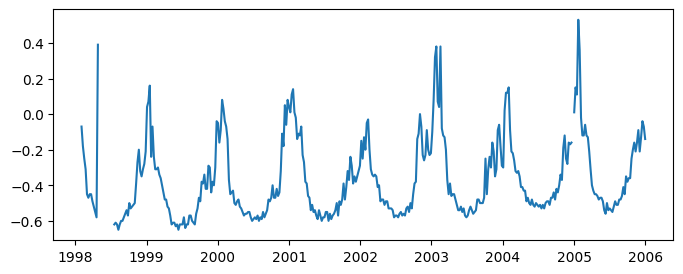

In [5]:
# Plot
plt.figure(figsize=(8, 3))  # width=12, height=6 inches
plt.plot(df.index,df.values)

15:25:48 - cmdstanpy - INFO - Chain [1] start processing
15:25:48 - cmdstanpy - INFO - Chain [1] done processing


Text(0, 0.5, 'original data')

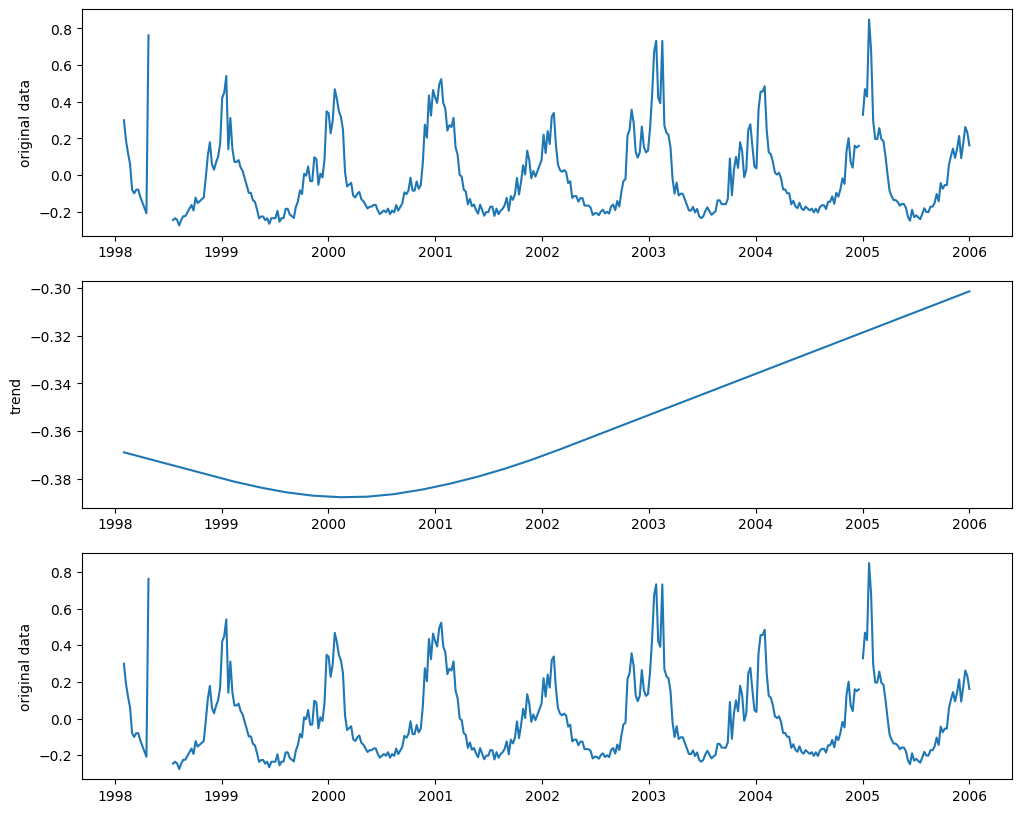

In [6]:
df_prophet = df.copy()
df_prophet = df_prophet.reset_index()
df_prophet.columns = ["ds","y"]
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet.index = df_prophet["ds"]

nan_idx = np.where(df_prophet["y"].isna())[0]
df_prophet["y"] = df_prophet["y"].interpolate()

# Run Prophet
prophet_model = Prophet()
prophet_model.fit(df_prophet)
phophet_results = prophet_model.predict(df_prophet[["ds"]])
 
trend = phophet_results["trend"]
detrend_data = df_prophet["y"].values - trend.values
detrend_data[nan_idx] = np.nan
df_prophet["y"] = detrend_data

# plot prophet decomposition
fig, axes = plt.subplots(3, 1, figsize=(12,10))
axes[0].plot(df_prophet["ds"], df_prophet["y"])
axes[0].set_ylabel("original data")
axes[1].plot(df_prophet["ds"], trend)
axes[1].set_ylabel("trend")
axes[2].plot(df_prophet["ds"], detrend_data)
axes[2].set_ylabel("original data")

In [7]:
df_detrend = df_prophet.copy()
df_detrend = df_detrend.drop(columns=["ds"], errors="ignore")
df_detrend.columns = [sensor_name]

In [8]:
df_detrend.head()

,LTU001EFAPRG900
ds,
1998-02-01,0.298879
1998-02-08,0.189107
1998-02-15,0.119335
1998-02-22,0.059564
1998-03-01,-0.080208


In [10]:
UpdateCsv(
    df_detrend,
    values_path="/Users/vuongdai/GitHub/bm/detrend_data/weekly/week_values.csv",
    datetimes_path="/Users/vuongdai/GitHub/bm/detrend_data/weekly/week_datetimes.csv",
    rewrite=True,
    )

Column name to check: 'LTU001EFAPRG900'
Added 'LTU001EFAPRG900' values to '/Users/vuongdai/GitHub/bm/detrend_data/weekly/week_values.csv'.
Added 'LTU001EFAPRG900' index to '/Users/vuongdai/GitHub/bm/detrend_data/weekly/week_datetimes.csv'.
